In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from pathlib import Path
import json
from scoit.cell_analysis import umap_visualize
from hgnn.hypergraph import *

In [2]:
# from examples.case_studies.SCoPE2_analysis import load_data
#
# expression_data, methylation_data, labels = load_data()

sample = np.load('./data/SCoPE2/sample10.npz', allow_pickle=True)
labels, expression_data, methylation_data = sample['labels'], sample['expression_data'], sample['methylation_data']

In [3]:
# train_labels, _, train_expression, _, train_methylation, _ = train_test_split(labels, expression_data, methylation_data,
#                                                                      train_size=0.1, stratify=labels, random_state=42)
# np.savez('./data/SCoPE2/sample10', labels=train_labels, expression_data=train_expression, methylation_data=train_methylation)
# train_labels.shape, train_expression.shape, train_methylation.shape

In [4]:
len(labels), expression_data.shape, methylation_data.shape

(149, (149, 3042), (149, 3042))

<Axes: >

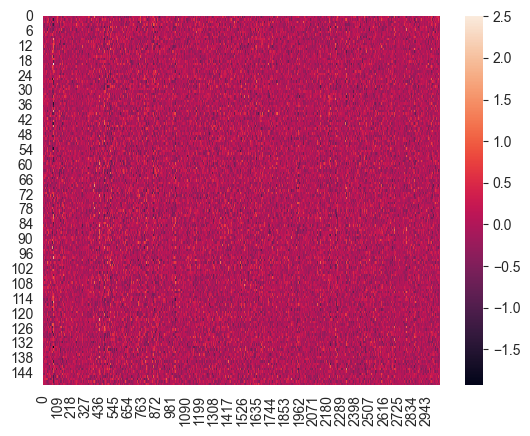

In [5]:
sns.heatmap(methylation_data)

In [6]:
methylation_data.min(), methylation_data.max()

(np.float64(-1.931922039), np.float64(2.507230229))

<Axes: >

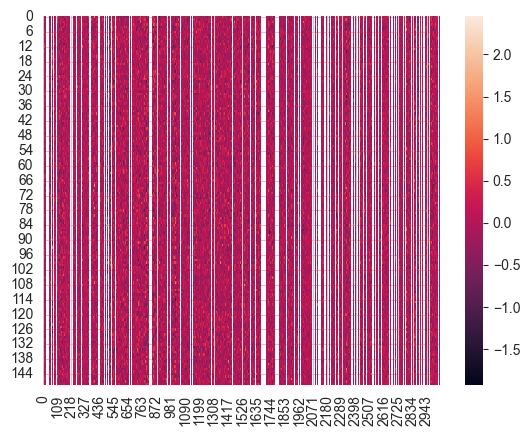

In [7]:
sns.heatmap(expression_data)

In [8]:
expression_data.min(), expression_data.max()

(np.float64(nan), np.float64(nan))

In [9]:
def remove_all_nan_columns(data, remove_all_zeros=True, sigma=0):
    print('Input #cols', data.shape[1])
    valid_cols = np.all(~np.isnan(data), axis=0)
    data = data[:, valid_cols]
    print('After remove all nan', data.shape[1])

    if remove_all_zeros:
        # 删除全是0的列。
        valid_cols = ~np.all(np.abs(data) < 1e-5, axis=0)
        data = data[:, valid_cols]
        print('After remove all zeros', data.shape[1])
    if sigma > 0:
        data = np.exp(data / sigma)
    return data

In [10]:
expression_data_clean = remove_all_nan_columns(expression_data, sigma=10)
methylation_data_clean = remove_all_nan_columns(methylation_data, sigma=10)

Input #cols 3042
After remove all nan 2272
After remove all zeros 2272
Input #cols 3042
After remove all nan 3042
After remove all zeros 3042


In [11]:
np.any(np.abs(expression_data_clean) < 1e-5), np.any(np.abs(methylation_data_clean) < 1e-5)

(np.False_, np.False_)

In [12]:
expression_data_clean.min(), expression_data_clean.max()

(np.float64(0.8244582477031518), np.float64(1.2790284914534515))

In [13]:
methylation_data_clean.min(), methylation_data_clean.max()

(np.float64(0.8243235207163697), np.float64(1.284954132169011))

Text(0.5, 1.0, 'methylation_data_clean')

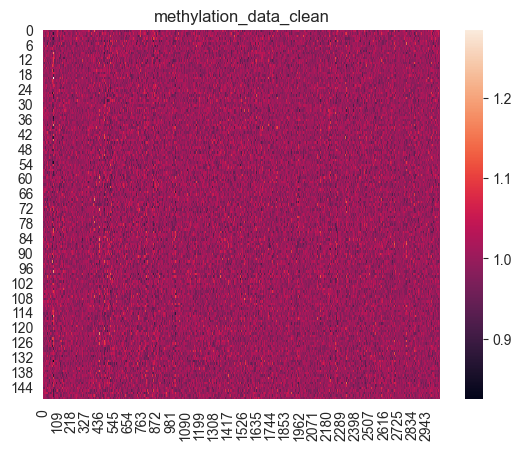

In [14]:
sns.heatmap(methylation_data_clean)
plt.title('methylation_data_clean')

Text(0.5, 1.0, 'expression_data_clean')

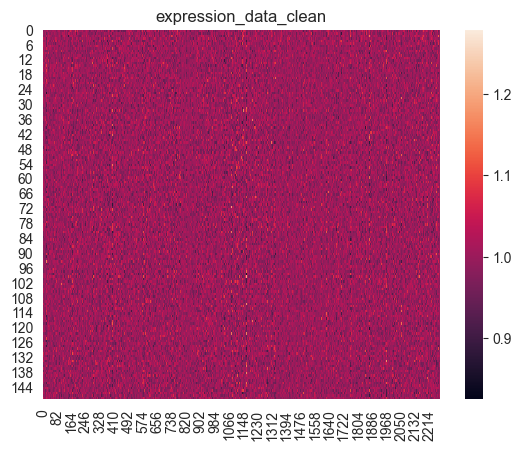

In [15]:
sns.heatmap(expression_data_clean)
plt.title('expression_data_clean')

In [16]:
def get_edges_weights_from_omics(data, omics_id, gene_offset):
    edges = np.nonzero(np.abs(data) > 1e-5)
    weights = data[edges]
    edges = edges + (np.ones_like(edges[0]) * omics_id, )
    edges = np.array(edges).T
    assert np.all(edges.max(0)[:-1] == np.array(data.shape) - 1)
    edges[:, 1] += gene_offset
    return edges, weights

In [17]:
expression_edges, expression_weights = get_edges_weights_from_omics(expression_data_clean, 0, 0)
methylation_edges, methylation_weights = get_edges_weights_from_omics(methylation_data_clean, 1, expression_data_clean.shape[1])

In [18]:
expression_edges.shape, expression_weights.shape, methylation_edges.shape, methylation_weights.shape

((338528, 3), (338528,), (453258, 3), (453258,))

In [19]:
def concat_edges_weights(edges_list, weights_list):
    return np.concatenate(edges_list, axis=0), np.concatenate(weights_list, axis=0)

In [20]:
edges, weights = concat_edges_weights([expression_edges, methylation_edges], [expression_weights, methylation_weights])

In [21]:
weights.min(), weights.max()

(np.float64(0.8243235207163697), np.float64(1.284954132169011))

In [22]:
np.any(np.abs(weights) < 1e-5)

np.False_

In [23]:
edges.shape, weights.shape

((791786, 3), (791786,))

In [24]:
save_edges_and_weights('./data/SCoPE2', edges=edges, weights=weights, train_size=0.8, normalization=False)

In [25]:
train_data = np.load('./data/SCoPE2/train_data.npz', allow_pickle=True)
test_data = np.load('./data/SCoPE2/test_data.npz', allow_pickle=True)

In [26]:
train_data['nums_type']

array([ 149, 5314,    2])

Negative entries cannot be used. BUT WHY?

In [27]:
!mkdir -p ./embeddings/hgnn/SCoPE2

In [36]:
!python hgnn/main_torch_zinb.py --data SCoPE2 --feature adj --loss bce --iter 50 --batch_size 256 && mv *.npy ./embeddings/hgnn/SCoPE2

1.0 -0.5
model_no_randomwalk
Use train_weight (791786,)
Node type num [ 149 5314    2]
embeddings_initial [np.False_, np.False_, np.False_]
[0.9604425 1.0027112 1.0135674 ... 0.9965394 1.0345535 0.9294983] 0.82432353 1.2849542
walk type 
adding pad idx
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
dict_size 791786 791786
train data amount 791786
64
tensor([   0,  149, 5463, 5465], device='mps:0')
w.shape (149, 5316)
(149, 5316)
w.shape (5314, 151)
(5314, 151)
w.shape (2, 5463)
(2, 5463)
self.input_size [5316, 151, 5463]
inp 5316 out 64 weight.shape torch.Size([64, 5316])
fan_in 5316 72.91090453423274
inp 151 out 64 weight.shape torch.Size([64, 151])
fan_in 151 12.288205727444508
inp 5463 out 64 weight.shape torch.Size([64, 5463])
fan_in 5463 73.91210996852952
params to be trained 1129109
batch size 256
[ Epoch 0 of 50 ]
  - (Training)   bce:  0.3080, ski

In [40]:
!mv *.npy ./embeddings/hgnn/SCoPE2

In [41]:
cell_embeddings = np.load('./embeddings/hgnn/SCoPE2/mymodel_0.npy', allow_pickle=True)

In [42]:
cell_embeddings.shape

(149, 64)

/Users/fengcong/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


{'NMI': 0.0, 'ARI': 0.0, 'FMI': 0.7816134879060695}

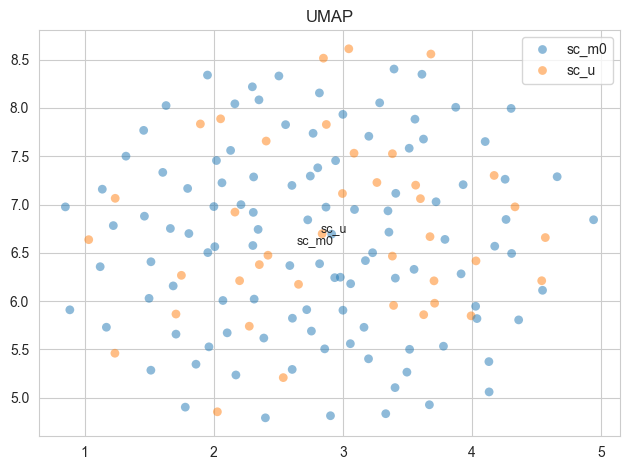

In [43]:
umap_visualize(cell_embeddings, labels)